<a href="https://colab.research.google.com/github/mkane968/digital-text-methods/blob/main/Tutorial_3_Metadata_Exploration_and_Corpus_Construction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metadata Exploration and Corpus Construction

Today we will use metadata from Project Gutenberg to explore how a large digital collection can become a research corpus.

Our main question is:

**How do the decisions we make when constructing a corpus shape the claims we can make from it?**

As you work, consider:

- What texts are available?
- What metadata describes them?
- What information is missing?
- What gets included or excluded when we filter the collection?
- Is our resulting corpus balanced, representative, purposive, or opportunistic?
- What claims could we reasonably make from it?

In [1]:
# Import packages for constructing a dataframe and plotting
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load the Project Gutenberg Catalog

Project Gutenberg provides downloadable metadata describing the texts in its collection.

Rather than beginning with the full text of thousands of books, we will begin with the **metadata**. Metadata is "data about data": information such as title, author, language, subject, and Gutenberg release date.

Let's download the current Project Gutenberg catalog.

In [2]:
# Retrieve metadata from url
url = "https://www.gutenberg.org/cache/epub/feeds/pg_catalog.csv"

metadata = pd.read_csv(url)

In [3]:
metadata.head()

,Text#,Type,Issued,Title,Language,Authors,Subjects,LoCC,Bookshelves
0,1,Text,1971-12-01,The Declaration of Independence of the United ...,en,"Jefferson, Thomas, 1743-1826","United States -- History -- Revolution, 1775-1...",E201; JK,Politics; American Revolutionary War; United S...
1,2,Text,1972-12-01,The United States Bill of Rights\r\nThe Ten Or...,en,United States,Civil rights -- United States -- Sources; Unit...,JK; KF,Politics; American Revolutionary War; United S...
2,3,Text,1973-11-01,John F. Kennedy's Inaugural Address,en,"Kennedy, John F. (John Fitzgerald), 1917-1963",United States -- Foreign relations -- 1961-196...,E838,"Category: Essays, Letters & Speeches; Category..."
3,4,Text,1973-11-01,Lincoln's Gettysburg Address\r\nGiven November...,en,"Lincoln, Abraham, 1809-1865",Consecration of cemeteries -- Pennsylvania -- ...,E456,"US Civil War; Category: Essays, Letters & Spee..."
4,5,Text,1975-12-01,The United States Constitution,en,United States,United States -- Politics and government -- 17...,JK; KF,United States; Politics; American Revolutionar...


### Stop and Look

Before doing anything else, examine the table.

What does Project Gutenberg record about its texts?

What information would you want to know about these texts that is **not** included here?

In [4]:
#Get teh shape of the metadata
metadata.shape

(79381, 9)

In [5]:
#Interpret the shape
print("Number of records:", len(metadata))
print("Number of metadata fields:", len(metadata.columns))

Number of records: 79381
Number of metadata fields: 9


In [6]:
#Append column names to list
metadata.columns.tolist()

['Text#',
 'Type',
 'Issued',
 'Title',
 'Language',
 'Authors',
 'Subjects',
 'LoCC',
 'Bookshelves']

In [7]:
#Get # rows in each column where data is missing
metadata.isna().sum()

,0
Text#,0
Type,0
Issued,0
Title,0
Language,0
Authors,165
Subjects,38
LoCC,251
Bookshelves,3685


### Stop and Look

Look at the available variables and the missing values.

Consider:

1. Which variables could be useful for constructing a literary corpus?
2. Which variables have substantial missing information?
3. What information about literary history, authorship, identity, genre, or publication is unavailable?
4. How might the available metadata influence the kinds of research questions we are able to ask?


## 2. Explore the Metadata

Examine the available categories of metadata and consider what they reveal about the texts. Project Gutenberg provides the following metadata:

- **Text#** – Project Gutenberg’s unique identification number for the text.
- **Type** – The type of digital resource, such as text, sound, or moving image.
- **Issued** – The date the Project Gutenberg edition was released. **Note:** this is not the original publication date of the work.
- **Title** – The title of the work as recorded by Project Gutenberg.
- **Language** – The language or languages of the text, represented using language codes (for example, `en` for English).
- **Authors** – The author or creator associated with the work. Entries may also include birth and death years when known.
- **Subjects** – Subject headings assigned to the work, generally based on Library of Congress Subject Headings. These can describe topics, genres, characters, places, or other characteristics.
- **LoCC** – Library of Congress Classification codes that identify broad subject areas (for example, `PR` for English literature).
- **Bookshelves** – Project Gutenberg's own thematic or genre-based groupings of texts, such as "Gothic Fiction," "Children's Literature," or "Science Fiction."

Further information about the metadata can be found here: https://www.gutenberg.org/ebooks/offline_catalogs.html

In [8]:
#Look at languages represented in the collection
metadata["Language"].value_counts().head(15)

,count
Language,
en,62860
fr,4190
fi,3684
de,2425
it,1110
nl,1109
es,893
hu,654
pt,647


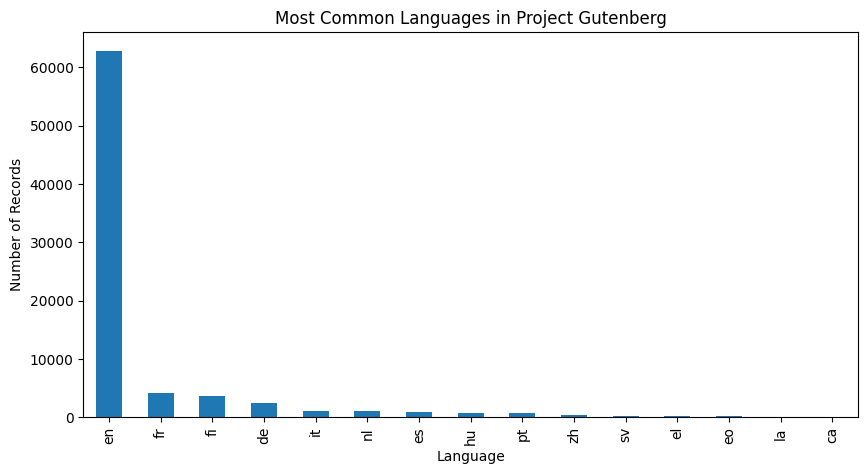

In [9]:
#Graph of languages
metadata["Language"].value_counts().head(15).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Most Common Languages in Project Gutenberg")
plt.xlabel("Language")
plt.ylabel("Number of Records")
plt.show()

### What exactly are we looking at?

What does this graph represent?

Is it:

- the distribution of languages in literature?
- the distribution of languages in published literature?
- the distribution of languages in public-domain literature?
- the distribution of languages in Project Gutenberg?

Why do these distinctions matter?

In [10]:
#Identify authors in the collection
metadata["Authors"].value_counts().head(20)

,count
Authors,
Various,2789
Anonymous,880
"Lytton, Edward Bulwer Lytton, Baron, 1803-1873",217
"Twain, Mark, 1835-1910",191
"Shakespeare, William, 1564-1616",168
"Various; Burnand, F. C. (Francis Cowley), 1836-1917 [Editor]",142
"Oliphant, Mrs. (Margaret), 1828-1897",137
Unknown,136
"Various; Bell, George, 1814-1890 [Editor]",135


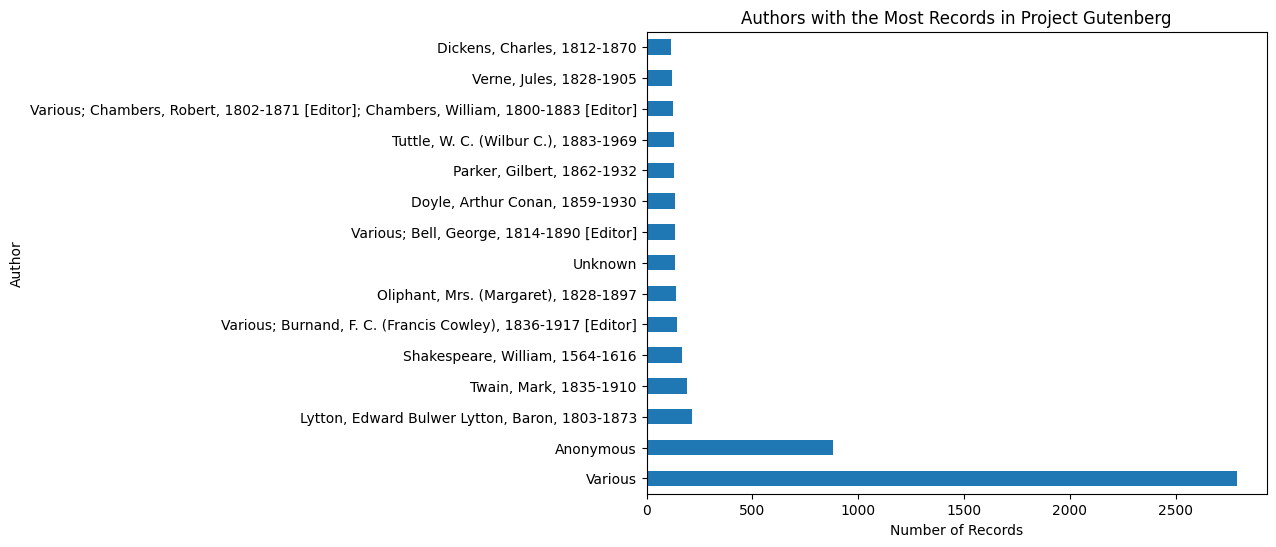

In [11]:
#Map the authors
metadata["Authors"].value_counts().head(15).plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Authors with the Most Records in Project Gutenberg")
plt.xlabel("Number of Records")
plt.ylabel("Author")
plt.show()


### Consider representation

Why might some authors have substantially more texts represented than others?

Does a large number of texts by an author mean that author was more important, more popular, or more representative of literary history?

What other processes might explain this pattern?

In [12]:
# Look at subjects
metadata["Subjects"].dropna().head(20)

,Subjects
0,"United States -- History -- Revolution, 1775-1..."
1,Civil rights -- United States -- Sources; Unit...
2,United States -- Foreign relations -- 1961-196...
3,Consecration of cemeteries -- Pennsylvania -- ...
4,United States -- Politics and government -- 17...
5,"Speeches, addresses, etc., American; United St..."
6,"Massachusetts -- History -- New Plymouth, 1620..."
7,United States -- Politics and government -- 18...
8,United States -- Politics and government -- 18...
9,Bible


In [14]:
#Find all subjectts containing "Fiction"
fiction = metadata[
    metadata["Subjects"].str.contains(
        "fiction",
        case=False,
        na=False
    )
]

print("Records containing 'fiction' in Subjects:", len(fiction))

fiction[["Title", "Authors", "Language", "Subjects"]].head(20)

Records containing 'fiction' in Subjects: 30882


,Title,Authors,Language,Subjects
10,Alice's Adventures in Wonderland,"Carroll, Lewis, 1832-1898",en,Fantasy fiction; Children's stories; Imaginary...
11,Through the Looking-Glass,"Carroll, Lewis, 1832-1898",en,Fantasy fiction; Children's stories; Imaginary...
14,"Moby-Dick; or, The Whale","Melville, Herman, 1819-1891",en,Whaling -- Fiction; Sea stories; Psychological...
15,Peter Pan,"Barrie, J. M. (James Matthew), 1860-1937",en,Fantasy literature; Peter Pan (Fictitious char...
23,O Pioneers!,"Cather, Willa, 1873-1947",en,Nebraska -- Fiction; Historical fiction; Front...
26,Far from the Madding Crowd,"Hardy, Thomas, 1840-1928",en,Didactic fiction; Love stories; Triangles (Int...
31,Herland,"Gilman, Charlotte Perkins, 1860-1935",en,Utopias -- Fiction; Women -- Fiction; Utopian ...
32,The Scarlet Letter,"Hawthorne, Nathaniel, 1804-1864",en,Adultery -- Fiction; Historical fiction; Reven...
34,The Time Machine,"Wells, H. G. (Herbert George), 1866-1946",en,Science fiction; Time travel -- Fiction; Dysto...
35,The war of the worlds,"Wells, H. G. (Herbert George), 1866-1946",en,Science fiction; War stories; Martians -- Fict...


## 3. From Collection to Corpus

Project Gutenberg is a large collections. A research project generally requires us to construct a more specific corpus from that collection.

Suppose our project is interested in fiction written in English.

We now need to make decisions about what counts.

In [15]:
#Get only texts written in English
english = metadata[
    metadata["Language"].str.contains(
        "en",
        case=False,
        na=False
    )
]

print("English-language records:", len(english))

English-language records: 63045


In [16]:
# Get only texts written in English that contain fiction as one of their subjects
english_fiction = metadata[
    metadata["Language"].str.contains("en", case=False, na=False)
    &
    metadata["Subjects"].str.contains("fiction", case=False, na=False)
]

print("English fiction records:", len(english_fiction))

English fiction records: 24054


In [17]:
#Show English Fiction corpus
english_fiction[
    ["Title", "Authors", "Language", "Subjects"]
].sample(10)

,Title,Authors,Language,Subjects
64193,Original stories from real life\r\nWith conver...,"Wollstonecraft, Mary, 1759-1797",en,"Children's stories, English; Didactic fiction,..."
43278,"In the Depths of the Dark Continent; or, The V...","Shea, Cornelius, 1863-1920",en,Revenge -- Fiction; Young men -- Fiction; Adve...
65646,John Harper's Insight,"Purcell, Dick",en,Science fiction; Short stories; Pianists -- Fi...
8606,Indian Tales,"Kipling, Rudyard, 1865-1936",en,India -- Social life and customs -- Fiction; S...
740,James Pethel,"Beerbohm, Max, Sir, 1872-1956",en,Short stories; Character sketches; Gambling --...
74160,In love's hands,"Clay, Bertha M., 1865-1922",en,England -- Fiction; Man-woman relationships --...
33992,The Sentimental Adventures of Jimmy Bulstrode,"Van Vorst, Marie, 1867-1936; Kimball, Alonzo, ...",en,Married women -- Fiction; Rich people -- Ficti...
61587,Stories of Intellect,"Johnson, Rossiter, 1840-1931 [Editor]; Davis, ...",en,Fiction; Short stories
17037,The House of the Misty Star\nA Romance of Yout...,"Little, Frances, 1863-1941",en,Japan -- Fiction
69694,"The Piccinino, Volume 2 (of 2); The last of Al...","Sand, George, 1804-1876; Cortazzo, Oreste, 183...",en,French fiction -- Translations into English


### Stop and Look

Read the ten randomly selected records.

Does this look like what you expected when you heard "English-language fiction"?

Identify:

- one text that clearly fits your expectations;
- one that surprised you;
- one record whose inclusion you might question.

What does this tell us about relying on metadata categories to construct a corpus?

## Corpus Construction Challenge

Construct a potential corpus using the available metadata.

Your corpus should contain approximately **20–100 texts**.

You may filter according to variables such as:

- subject
- language
- author
- Library of Congress classification
- bookshelf
- Gutenberg release date

Record every filtering decision you make.

For each decision, ask:

**What did this decision include? What did it exclude?**

In [18]:
# Build your corpus here
my_corpus = metadata.copy()



In [ ]:
# Check the metadata columns for listed values

# EXAMPLE: Check all values in Language column
my_corpus["Language"].value_counts().head(15)

In [ ]:
#Filter by specific values

#Example: Get only texts written in English
english = my_corpus[
    my_corpus["Language"].str.contains(
        "en",
        case=False,
        na=False
    )
]


In [ ]:
# Show results from your corpus (run after adding filters)
print("Number of texts:", len(my_corpus))

print("\nLanguages:")
print(my_corpus["Language"].value_counts())

print("\nMost common authors:")
print(my_corpus["Authors"].value_counts().head(10))

In [ ]:
#Print out a subset from your corpus
my_corpus[
    ["Title", "Authors", "Language", "Subjects"]
].sample(min(10, len(my_corpus)))

In [ ]:
# Plot the most represented authors in your corpus
my_corpus["Authors"].value_counts().head(10).plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Most Represented Authors in My Corpus")
plt.xlabel("Number of Texts")
plt.ylabel("Author")
plt.show()

### From Gutenberg to Your Corpus

You will eventually construct a corpus for your own research project. Your corpus may come from Gutenberg, another digital collection, texts you collect yourself, or multiple sources.

As you explore Gutenberg's metadata, think about what **your corpus** will need.

Consider:

1. **What is your unit of analysis?**  
   What will one "row" in your dataset represent—a novel, poem, article, chapter, speech, review, author, or something else?

2. **What basic information will you need to identify each text?**  
   For example: title, author, date, source, unique ID, or filename.

3. **What metadata will you need to answer your research question?**  
   For example: genre, publication year, author, gender, publication venue, nationality, literary period, topic, or audience.

4. **Which metadata already exists, and which will you have to create or code yourself?**

5. **Where will your metadata come from?**  
   Consider whether it comes from the texts themselves, an archive or repository, a catalog, another dataset, or your own research.

6. **What might be difficult to categorize?**  
   Are any of your categories interpretive, uncertain, incomplete, or historically complicated?



### Start Planning Your Metadata

Create a preliminary list of **5–10 metadata fields** you think you might want for your own corpus.

| Metadata Field | Why Do I Need It? | Where Will It Come From? |
|---|---|---|
| Title | Identify each text | Source collection |
| Publication year | Compare texts over time | Bibliographic research |
| Genre | Compare genres | Repository / my coding |
| ______ | ______ | ______ |

## References

- Fileva, P. (2023). *Introduction to corpus building*. *Survey of Methods in Computational Literary Studies*. https://methods.clsinfra.io/corpus-intro.html

- Beelen, K., Lawrence, J., Wilson, D. C. S., & Beavan, D. (2023). Bias and representativeness in digitized newspaper collections: Introducing the environmental scan. *Digital Scholarship in the Humanities, 38*(1), 1–22. https://doi.org/10.1093/llc/fqac037

- Piper, A. (2022). Biodiversity is not declining in fiction. *Computational Humanities Research, 2*, 225–245. https://doi.org/10.22148/001c.38739

- D’Ignazio, C., & Klein, L. F. (2020). What gets counted counts. In *Data Feminism*. MIT Press. https://data-feminism.mitpress.mit.edu/pub/h1w0nbqp/release/1